<a href="https://colab.research.google.com/github/Laurasgrv-colab/PRe/blob/main/gaussian_bayesian_logistic_regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Case Study : Bayesian logistic regression with a gaussian prior via SOUL variants

This notebook includes my implementation of the SOUL algorithm and my non-differential variants applied to the Bayesian logistic regression example with a gaussian prior in Section 3.1 of [Particle algorithms for maximum likelihood training of latent variable models](https://juankuntz.github.io/publication/parem/).  

In [15]:
import numpy as np
import matplotlib.pyplot as plt

#@title Load modules.

# Install the wget and sklearn packages (if running the notebook locally,
# comment the following lines out).
!pip install wget
#%pip install scikit-learn

# OS and wget to load dataset.
import os
import wget
from scipy.stats import norm



[notice] A new release of pip is available: 25.3 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [16]:
#@title Load and normalize the Wisconsin Breast Cancer dataset.

# Fetch dataset from repository:
wget.download('https://archive.ics.uci.edu/ml/machine-learning-databases/breast-cancer-wisconsin/breast-cancer-wisconsin.data')

# Load dataset:
dataset = np.loadtxt('breast-cancer-wisconsin.data', dtype=str, delimiter=',')

# Delete local copy of dataset to avoid duplicates with multiple notebook runs:
os.remove('breast-cancer-wisconsin.data')

# Remove datapoints with missing attributes and change dtype to float:
dataset = dataset[~(dataset == '?').any(axis=1), :].astype(float)

# Extract features and labels, and normalize features:
features = np.array(dataset[:, 1:10] - dataset[:, 1:10].mean(0))
features = features/features.std(0)
labels = np.array([(dataset[:, 10]-2)/2]).transpose()

# SOUL function.

In [17]:
#@title SOUL function
# This is my own SOUL function
def soul(log_p_grad_x, th0, x0_M, y_l, y_f, T, M, B, delta_step, gamma_step):
  """
    Stochastic Optimisation via Unadjusted Langevin (SOUL).

    Parameters:
    - log_p_grad_x: Function returning grad_x log p(th, X, y). Shape matches X.
    - log_p_grad_th: Function returning grad_theta log p(th, X, y). Shape matches theta.
    - th_0: Initial parameters
    - x0_M: Initial latent variables from the previous step
    - y_l, y_f: Observed data
    - T: Number of outer optimization steps
    - M: Number of Langevin steps
    - B: Burn-in steps
    - delta_step: Step size for theta update
    - gamma_step: Langevin step size
    """
  th = np.copy(th0)
  x_t = np.copy(x0_M[:, 0:1]).reshape(D,1) # shape (D,1) (instead of (D,)) - keeps the column dimension

  x_values = np.array(x0_M)
  th_list = [th0]
  for t in range(1, T+1):

    # ULA steps
    for m in range(1, M+1):
      grad_x = log_p_grad_x(th, x_t, y_l, y_f)
      Z_k = np.random.normal(0.0, 1.0, x_t.shape) # Force size

      # Compute new x
      x_t += gamma_step * grad_x + np.sqrt(2.0 * gamma_step) * Z_k
      x_values = np.append(x_values, np.copy(x_t), axis=1) # Store new position

    burnin_x_samples = x_values[:, -(M-B):] # Shape (D, M-B)

    # Compute new theta
    avg_grad_th = np.zeros_like(th) # th is (1,1), so avg_grad_th is (1,1)

    # Iterate over particles (columns) instead of feature dimensions (rows)
    for idx in range(M-B):
      x_m_burnin = burnin_x_samples[:, idx:idx+1] # Shape (D,1)
      # (x_m_burnin - th) will broadcast to (D, 1).
      # We first sum only along D with .sum(0), then average over M-B.
      avg_grad_th += ((x_m_burnin - th).sum(0) / 5)

    th = th + delta_step * avg_grad_th /(M-B) # Update theta
    th_list.append(np.copy(th)) # Store new theta

  return th_list, x_values

And this is the gradient function specific to the problem.

In [18]:
def log_p_grad_x(th, x, y_l, y_f):
  s = 1/(1+np.exp(- np.matmul(y_f, x)))
  return np.matmul((y_l-s).transpose(), y_f).transpose() - 2*(x-th)/5


This is the SOUL function produced by Kuntz et al. for their *Particle algorithms for maximum likelihood training of latent variable models* (2023) article, that can be found [here](https://github.com/juankuntz/ParEM/blob/main/README.md).
We will use this as a 'control' to compare our results and the performance of our SOUL function.

In [19]:
#@title SOUL control
def soul_ctrl(l, f, h, K, N, th, X):
    for k in range(K):
        # Run ULA chain:
        for n in range(N):
            Xkn = X[:, -1].reshape(D, 1)  # Extract current particle position.
            # Take a step:
            Xknp1 = (Xkn + h*grad_x(th[k], Xkn, l, f)
                          + np.sqrt(2*h)*np.random.normal(0, 1, (D, 1)))
            X = np.append(X, Xknp1, axis=1)  # Store new particle position.
        th = np.append(th, th[k] + h*ave_grad_th(th[k], X[:, -N:]))  # Update theta.
    return th, X

    # Auxiliary functions.

def ave_grad_th(th, x):
    """Returns theta-gradient of log density averaged over particle cloud."""
    return ((x-th).sum(0)).mean()/5

def grad_x(th, x, l, f):
    """Returns x-gradient of log density vectorized over particles."""
    s = 1/(1+np.exp(- np.matmul(f, x)))
    return np.matmul((l-s).transpose(), f).transpose() - 2*(x-th)/5

# SOUL variants

As explained in the report, it is frequent that we can not derive the gradient of the prior p. Therefore, we wish to test and compare different gradient-free variants of the SOUL algorithm on this example. Here is our auxiliary function for this:

In [20]:
def log_p(th, x, y_l, y_f):
    f_T_x = np.dot(y_f, x)
    log_lik = np.sum(y_l*f_T_x - np.log(1+np.exp(f_T_x)))
    log_prior = np.sum((x-th) ** 2) / 5.0
    return log_lik - log_prior

This is our first variant: soul_mh uses Metropolis-Hastings instead of ULA.

In [21]:

#@title SOUL with Metropolis-Hastings.
def so_mh(log_p, th0, x0_M, y_l, y_f, T, M, B, delta_step, proposal_std):
  """
  SOUL where the latent sampling is done via Metropolis-Hastings (MH) instead of ULA.

  Parameters:
  - log_p: Function returning log p(th, X, y_l, y_f). Returns a scalar float.
  - th0: Initial parameters
  - x0_M: Initial latent variables from the previous step
  - y_l, y_f: Observed data
  - T: Number of outer optimization steps
  - M: Number of MH steps
  - B: Burn-in steps
  - delta_step: Step size for theta update
  - proposal_std: Standard deviation of the Gaussian random walk proposal (replaces gamma_step)
  """
  th = np.copy(th0)
  x_t = np.copy(x0_M[:, 0:1]).reshape(D, 1)

  x_values = np.array(x0_M)
  th_list = [np.copy(th)]
  al=0

  for t in range(1, T + 1):

    # Metropolis-Hastings step
    for m in range(1, M + 1):
      z = np.random.normal(0.0, 1.0, x_t.shape)
      x_prop = x_t + proposal_std*z

      # The proposal is symmetri ie. q(x_t | x_prop) = q(x_prop | x_t), so the proposal ratio cancels out.
      log_alpha = min(0, log_p(th, x_prop, y_l, y_f) - log_p(th, x_t, y_l, y_f))

      # Accept or reject
      if np.log(np.random.uniform(0.0, 1.0)) < log_alpha:
          x_t = x_prop # Accept proposal
      # else: x_t remains the same

      # Store the current position (accpted or not)
      x_values = np.append(x_values, np.copy(x_t), axis=1)

    burnin_x_samples = x_values[:, -(M-B):] # Shape (D, M-B)

    # Compute average gradient with respect to theta over the kept samples
    avg_grad_th = np.zeros_like(th)
    for idx in range(M - B):
      x_m_burnin = burnin_x_samples[:, idx:idx+1] # Shape (D, 1)
      # Use the provided theta gradient function
      avg_grad_th += ((x_m_burnin - th).sum(0) / 5)

    # Update theta
    th = th + delta_step * (avg_grad_th / (M - B))
    th_list.append(np.copy(th))

  return th_list, x_values

In [22]:
#@title SOUL MHSS
def so_mh_ss(log_p, th0, x0_M, y_l, y_f, T, M, B, delta_step, proposal_std, lower_bounds, upper_bounds):
  """
  SOUL where the latent sampling is done via Metropolis-Hastings with Standardised Scaling (MH SS).

  Parameters:
  - log_p: Function returning log p(th, X, y_l, y_f). Returns a scalar float.
  - th0: Initial parameters
  - x0_M: Initial latent variables from the previous step
  - y_l, y_f: Observed data
  - T: Number of outer optimization steps
  - M: Number of MH steps
  - B: Burn-in steps
  - delta_step: Step size for theta update
  - proposal_std: Standard deviation of the Gaussian random walk proposal in the [0, 1] space (typically 0.05 to 0.2)
  - lower_bounds: numpy array of shape (D, 1) containing the lower prior limits for X
  - upper_bounds: numpy array of shape (D, 1) containing the upper prior limits for X
  """
  th = np.copy(th0)
  D = x0_M.shape[0]
  x_t = np.copy(x0_M[:, 0:1]).reshape(D, 1)

  bounds_range = upper_bounds - lower_bounds

  x_values = np.array(x0_M)
  th_list = [np.copy(th)]

  for t in range(1, T + 1):

    for m in range(1, M + 1):
      # Transform current position to [0, 1] standardised space
      x_t_std = (x_t - lower_bounds) / bounds_range

      z = np.random.normal(0.0, 1.0, x_t.shape)
      x_prop_std = x_t_std + proposal_std * z

      # proposals must stay within [0, 1]
      if np.any(x_prop_std < 0.0) or np.any(x_prop_std > 1.0):
        # Out of bounds proposal: target density is effectively 0, so we reject it.
        x_values = np.append(x_values, np.copy(x_t), axis=1)
        continue

      x_prop = x_prop_std * bounds_range + lower_bounds

      # Since the proposal is symmetric in the standardised space and we reject
      # out-of-bounds proposals, the proposal ratio q(x_t | x_prop) / q(x_prop | x_t) remains 1.
      log_alpha = min(0, log_p(th, x_prop, y_l, y_f) - log_p(th, x_t, y_l, y_f))

      # Accept or reject
      if np.log(np.random.uniform(0.0, 1.0)) < log_alpha:
        x_t = x_prop

      # Store the current position
      x_values = np.append(x_values, np.copy(x_t), axis=1)

    burnin_x_samples = x_values[:, -(M - B):]

    avg_grad_th = np.zeros_like(th)
    for idx in range(M - B):
      x_m_burnin = burnin_x_samples[:, idx:idx + 1]  # Shape (D, 1)
      avg_grad_th += ((x_m_burnin - th).sum(0) / 5)

    # Update theta
    th = th + delta_step * (avg_grad_th / (M - B))
    th_list.append(np.copy(th))

  return th_list, x_values

In [23]:
def so_stretch(log_p, th0, x0_N, y_l, y_f, T, M, B, delta_step, a=2.0):
    th = np.copy(th0)
    D, N = x0_N.shape
    half = N // 2
    S = np.copy(x0_N)
    th_list = [th0]
    C_full = np.expand_dims(np.copy(S), axis=2)  # only for optional external inspection/plotting

    for t in range(1, T + 1):
        # Reset the per-iteration buffer: only states from THIS outer step are kept
        C_iter = np.expand_dims(np.copy(S), axis=2)

        for m in range(1, M + 1):
            indices = np.random.permutation(N)
            S1_idx, S2_idx = indices[:half], indices[half:]

            for ens_idx, comp_idx in [(S1_idx, S2_idx), (S2_idx, S1_idx)]:
                for i in ens_idx:
                    X_i = S[:, i:i+1]
                    j = np.random.choice(comp_idx)
                    X_j = S[:, j:j+1]

                    u_z = np.random.uniform(0.0, 1.0)
                    z = (a + (1/a) - 2)*(u_z**2) + 2*u_z*(1-(1/a)) + (1/a)
                    X_i_new = X_j + z * (X_i - X_j)

                    log_alpha = (D - 1) * np.log(z) + log_p(th, X_i_new, y_l, y_f) - log_p(th, X_i, y_l, y_f)

                    if np.log(np.random.uniform(0.0, 1.0)) < log_alpha:
                        S[:, i:i+1] = X_i_new

            C_iter = np.concatenate((C_iter, np.expand_dims(np.copy(S), axis=2)), axis=2)

        # Use ONLY this iteration's post-burn-in states
        burnin_ensemble_samples = C_iter[:, :, -(M - B):]  # Shape (D, N, M-B)
        flat_samples = burnin_ensemble_samples.reshape(D, -1)
        num_samples = flat_samples.shape[1]

        avg_grad_th = np.zeros_like(th)
        for idx in range(num_samples):
            x_m_burnin = flat_samples[:, idx:idx+1]
            avg_grad_th += ((x_m_burnin - th).sum(0) / 5)

        th = th + delta_step * avg_grad_th / num_samples
        th_list.append(np.copy(th))

        C_full = np.concatenate((C_full, C_iter[:, :, 1:]), axis=2)  # keep full history only for plotting/diagnostics

    return th_list, C_full   # fixed: was "return th_l" (NameError)

In [24]:
def so_stretch_fast(log_p, th0, x0_N, y_l, y_f, T, M, B, delta_step, a=2.0):
    th = np.copy(th0)
    D, N = x0_N.shape
    half = N // 2
    S = np.copy(x0_N)

    total_steps = T * M
    C = np.zeros((D, N, total_steps + 1))
    C[:, :, 0] = S

    th_list = [th0]
    global_step = 1

    for t in range(1, T + 1):
        iter_start = global_step  # mark where this outer iteration's states begin

        for m in range(1, M + 1):
            indices = np.random.permutation(N)
            S1_idx, S2_idx = indices[:half], indices[half:]

            for ens_idx, comp_idx in [(S1_idx, S2_idx), (S2_idx, S1_idx)]:
                n_ens = len(ens_idx)
                X_ens = S[:, ens_idx]
                rand_comp_indices = np.random.choice(comp_idx, size=n_ens)
                X_comp = S[:, rand_comp_indices]

                u_z = np.random.uniform(0.0, 1.0, size=(1, n_ens))
                z = ((a + (1.0/a) - 2.0)*(u_z**2) + 2.0*u_z*(1.0-(1.0/a)) + (1.0/a))
                X_new = X_comp + z * (X_ens - X_comp)

                log_p_cur = np.array([log_p(th, X_ens[:, i:i+1], y_l, y_f) for i in range(n_ens)])
                log_p_new = np.array([log_p(th, X_new[:, i:i+1], y_l, y_f) for i in range(n_ens)])
                log_alpha = (D - 1) * np.log(z.reshape(n_ens)) + log_p_new - log_p_cur

                accept_mask = np.log(np.random.uniform(0.0, 1.0, size=n_ens)) < log_alpha
                X_ens[:, accept_mask] = X_new[:, accept_mask]
                S[:, ens_idx] = X_ens

            C[:, :, global_step] = S
            global_step += 1

        # Use ONLY the states generated during this outer iteration
        flat_samples = C[:, :, iter_start:global_step].reshape(D, -1)
        avg_grad_th = np.mean((flat_samples - th).sum(axis=0) / 5.0)

        th = th + delta_step * avg_grad_th
        th_list.append(np.copy(th))

    return th_list, C

**Why this is better:** With our parameters (for eg. T=600, M=20 → 12,000 steps) and a cheap log_p, the dominant cost in the original version was likely the storage-growth (np.concatenate) rather than log_p.

**Time comparison:**
For parameters:
delta_step = 1e-2
gamma_step = 1e-2
T = 600  
M = 20  
B = 0
N=12
proposal_std = 0.25
- soul_stretch_fast took 16s
- soul_stretch took 5min

**Update details:**
- The inner "for i in ens_idx" loop over individual walkers was replaced with array-wide numpy operations.
- Pre-allocated storage for the chain C: Instead of growing C via repeated np.concatenate calls at every step (an O(T·M) sequence of reallocations), C is pre-allocated once with its final shape (D, N, T*M+1) and filled in-place via array slicing.
- Simplified theta gradient update: The manual accumulation-then-division (avg_grad_th += ... then / num_samples) was replaced with a single np.mean(...) call.
- Boolean-mask-based accept/reject step: Random acceptance decisions for all walkers in a half-ensemble are computed simultaneously as a boolean array (accept_mask), then applied in one vectorized assignment instead of an if statement inside the loop.

**Comments:** 
- the log-probability evaluation (log_p) is still computed via a Python list comprehension over each walker individually, since log_p itself is not batched — so this remains a per-walker loop in disguise. Vectorizing log_p itself would be needed for further speedup. Since the vectorisation of this function has revealed harder than expected, and the expected improvement is small, for time constraints to finish the project, we will keep this as it is.
- Additionnally, if N is odd, in the "for ens_idx, comp_idx in [(S1_idx, S2_idx), (S2_idx, S1_idx)]" loop, len(ens_idx) ≠ len(comp_idx), thus the "rand_comp_indices = np.random.choice(comp_idx, size=n_ens)" step. We chose a complementary walker j at random and independently (with return - the same j can be chosen for several i).


In [25]:

def so_walk(log_p, th0, x0_N, y_l, y_f, T, M, B, delta_step):
    th = np.copy(th0)
    D, N = x0_N.shape
    half = N // 2
    S = np.copy(x0_N)
    th_list = [th0]
    C_full = np.expand_dims(np.copy(S), axis=2)

    for t in range(1, T + 1):
        C_iter = np.expand_dims(np.copy(S), axis=2)  # reset per outer iteration

        for m in range(1, M + 1):
            indices = np.random.permutation(N)
            S1_idx, S2_idx = indices[:half], indices[half:]

            for ens_idx, comp_idx in [(S1_idx, S2_idx), (S2_idx, S1_idx)]:
                S_comp = S[:, comp_idx]
                Cov = np.cov(S_comp, ddof=0)
                if D == 1:
                    Cov = np.array([[Cov]])

                for i in ens_idx:
                    X_i = S[:, i:i+1]
                    W = np.random.multivariate_normal(np.zeros(D), Cov).reshape(D, 1)
                    X_i_new = X_i + W

                    log_alpha = log_p(th, X_i_new, y_l, y_f) - log_p(th, X_i, y_l, y_f)
                    if np.log(np.random.uniform(0.0, 1.0)) < log_alpha:
                        S[:, i:i+1] = X_i_new

            C_iter = np.concatenate((C_iter, np.expand_dims(np.copy(S), axis=2)), axis=2)

        burnin_ensemble_samples = C_iter[:, :, -(M - B):]  # only this iteration
        flat_samples = burnin_ensemble_samples.reshape(D, -1)
        num_samples = flat_samples.shape[1]

        avg_grad_th = np.zeros_like(th)
        for idx in range(num_samples):
            x_m_burnin = flat_samples[:, idx:idx+1]
            avg_grad_th += ((x_m_burnin - th).sum(0) / 5)

        th = th + delta_step * avg_grad_th / num_samples
        th_list.append(np.copy(th))

        C_full = np.concatenate((C_full, C_iter[:, :, 1:]), axis=2)

    return th_list, C_full

Let's implement equivalent improvements to soul_walk:

**Time comparison:**
For parameters:
delta_step = 1e-2
gamma_step = 1e-2
T = 600  
M = 20  
B = 0
N=12
proposal_std = 0.25
- soul_walk_fast took 19s
- soul_walk took took 6min

In [26]:
def so_walk_fast(log_p, th0, x0_N, y_l, y_f, T, M, B, delta_step):
    th = np.copy(th0)
    D, N = x0_N.shape
    half = N // 2
    S = np.copy(x0_N)

    total_steps = T * M
    C = np.zeros((D, N, total_steps + 1))
    C[:, :, 0] = S

    th_list = [th0]
    global_step = 1

    for t in range(1, T + 1):
        iter_start = global_step

        for m in range(1, M + 1):
            indices = np.random.permutation(N)
            S1_idx, S2_idx = indices[:half], indices[half:]

            for ens_idx, comp_idx in [(S1_idx, S2_idx), (S2_idx, S1_idx)]:
                n_ens = len(ens_idx)
                S_comp = S[:, comp_idx]
                Cov = np.cov(S_comp, ddof=0)
                if D == 1:
                    Cov = np.array([[Cov]])

                X_ens = S[:, ens_idx]
                W = np.random.multivariate_normal(np.zeros(D), Cov, size=n_ens).T
                X_prop = X_ens + W

                log_p_cur = np.array([log_p(th, X_ens[:, i:i+1], y_l, y_f) for i in range(n_ens)])
                log_p_prop = np.array([log_p(th, X_prop[:, i:i+1], y_l, y_f) for i in range(n_ens)])
                log_alpha = log_p_prop - log_p_cur

                accept_mask = np.log(np.random.uniform(0.0, 1.0, size=n_ens)) < log_alpha
                X_ens[:, accept_mask] = X_prop[:, accept_mask]
                S[:, ens_idx] = X_ens

            C[:, :, global_step] = S
            global_step += 1

        flat_samples = C[:, :, iter_start:global_step].reshape(D, -1)
        avg_grad_th = np.mean((flat_samples - th).sum(axis=0) / 5.0)

        th = th + delta_step * avg_grad_th
        th_list.append(np.copy(th))

    return th_list, C

# Figure 3a

Let's run the algorithm on 80/20 split of the data and plot the results.

In [27]:
#@title Set parameters
import numpy as np

# Split data into 80/20 training and testing sets:
from sklearn.model_selection import train_test_split
ftrain, ftest, ltrain, ltest = train_test_split(features, labels, test_size=0.2,
                                                random_state=0)

# Set approximation parameters:
delta_step = 1e-2 # Step-size, same for ULA and Langevin in this case.
gamma_step = 1e-2
T = 600  # Number of steps.
M = 20  # Number of particles.
B = 0 # There is no burn-in in this example.
proposal_std = 0.25 

# Initialize parameter estimates and particle cloud, all at zero:
D = features[0, :].size  # Dimension of latent space.
th0 = np.array([0.0])  # Parameter estimate, initialized as a (1,1) float array (scalar).
x0 = np.zeros((D, M))  # Particle cloud.

# Set reasonable lower and upper bounds for the latent variables.
lower_bounds = np.full((D, 1), 0.0) 
upper_bounds = np.full((D, 1), 5.0)  

N = 12  # Number of walkers (N>D)
x0_N = np.random.normal(0, 0.1, (D, N)) # Initialize x0_N with some slight noise



In [28]:
#@title Run algorithms:
proposal_std = 0.25
th_soul, x_soul = soul(log_p_grad_x, th0, x0, ltrain, ftrain, T, M, B, delta_step, gamma_step)


In [29]:
proposal_std = 0.25
th_so_mh, x_so_mh = so_mh(log_p, th0, x0, ltrain, ftrain, T, M, B, delta_step, proposal_std)


In [30]:
th_so_stretch, x_so_stretch = so_stretch(log_p, th0, x0_N, ltrain, ftrain, T, M, B, delta_step)


In [31]:

th_so_stretch_fast, x_so_stretch_fast = so_stretch_fast(log_p, th0, x0_N, ltrain, ftrain, T, M, B, delta_step)


In [32]:
th_so_walk, x_so_walk = so_walk(log_p, th0, x0_N, ltrain, ftrain, T, M, B, delta_step)


In [33]:
th_so_walk_fast, x_so_walk_fast = so_walk_fast(log_p, th0, x0_N, ltrain, ftrain, T, M, B, delta_step)


In [34]:
proposal_std = 0.1
th_so_mh_ss, x_so_mh_ss = so_mh_ss(log_p, th0, x0_N, ltrain, ftrain, T, M, B, delta_step, proposal_std, lower_bounds, upper_bounds)

In [35]:
# Compare to the control function
proposal_std = 0.25
th_ctrl, x_ctrl = soul_ctrl(ltrain, ftrain, delta_step, T, M, np.array([[0]]), x0)


Let's save the data:

In [36]:
import numpy as np

# Save the scalar parameter trajectories and time parameter T
np.savez_compressed(
    "so_all_theta_results.npz",
    T=T,
    th_soul=np.squeeze(th_soul),
    th_ctrl=np.squeeze(th_ctrl),
    th_so_mh=np.squeeze(th_so_mh),
    th_so_stretch=np.squeeze(th_so_stretch),
    th_so_walk=np.squeeze(th_so_walk),
    th_so_stretch_fast=np.squeeze(th_so_stretch_fast),
    th_so_walk_fast=np.squeeze(th_so_walk_fast),
    th_so_mh_ss=np.squeeze(th_so_mh_ss),
)

print("Data saved successfully to 'so_all_theta_results.npz'")

Data saved successfully to 'so_all_theta_results.npz'


And plot the results:

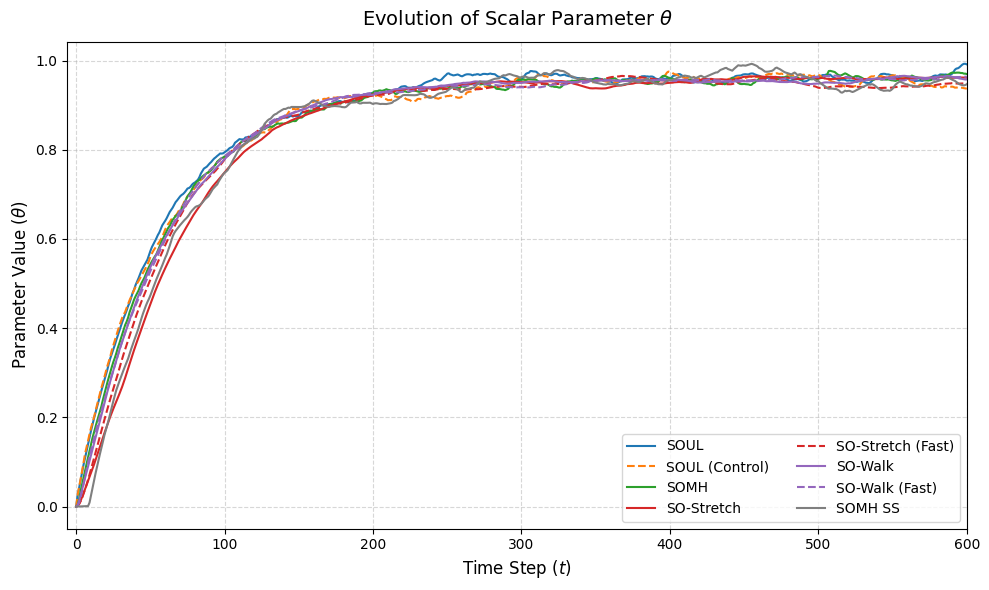

In [37]:
import matplotlib.pyplot as plt
import numpy as np

# Load the data
data = np.load("so_all_theta_results.npz")

T = data["T"]
th_soul = data["th_soul"]
th_ctrl = data["th_ctrl"]
th_so_mh = data["th_so_mh"]
th_so_stretch = data["th_so_stretch"]
th_so_walk = data["th_so_walk"]
th_so_stretch_fast = data["th_so_stretch_fast"]
th_so_walk_fast = data["th_so_walk_fast"]
th_so_mh_ss = data["th_so_mh_ss"]

# Plotting configuration
plt.figure(figsize=(10, 6))

# Custom line styles, colors, and labels
plt.plot(
    th_soul, label="SOUL", color="#1f77b4", linewidth=1.5
)  # Blue[cite: 1]
plt.plot(
    th_ctrl,
    label="SOUL (Control)",
    color="#ff7f0e",
    linestyle="--",
    linewidth=1.5,
)  
plt.plot(
    th_so_mh, label="SOMH", color="#2ca02c", linewidth=1.5
) 
plt.plot(
    th_so_stretch, label="SO-Stretch", color="#d62728", linewidth=1.5
) 

plt.plot(
    th_so_stretch_fast,
    label="SO-Stretch (Fast)",
    color="#d62728",
    linestyle="--",
    linewidth=1.5,
)  
plt.plot(
    th_so_walk, label="SO-Walk", color="#9467bd", linewidth=1.5
)  
plt.plot(
    th_so_walk_fast,
    label="SO-Walk (Fast)",
    color="#9467bd",
    linestyle="--",
    linewidth=1.5,
) 
plt.plot(
    th_so_mh_ss, label="SOMH SS", color="#7f7f7f", linewidth=1.5
)  

# Custom axes and titles
plt.xlim([-T / 100, T])  #[cite: 1]
plt.xlabel("Time Step ($t$)", fontsize=12)  #[cite: 1]
plt.ylabel(r"Parameter Value ($\theta$)", fontsize=12)  #[cite: 1]
plt.title(
    r"Evolution of Scalar Parameter $\theta$", fontsize=14, pad=12
)  #[cite: 1]

# Custom legend
plt.legend(loc="lower right", frameon=True, fontsize=10, ncol=2)  #[cite: 1]
plt.grid(True, linestyle="--", alpha=0.5)  #[cite: 1]

# Add a caption below the figure
"""
plt.figtext(
    0.5,
    -0.02,
    r"Figure 1: Comparison of $\theta$ convergence across different SOUL algorithm variants.",
    wrap=True,
    horizontalalignment="center",
    fontsize=10,
    style="italic",
)
"""

plt.tight_layout()
plt.show()

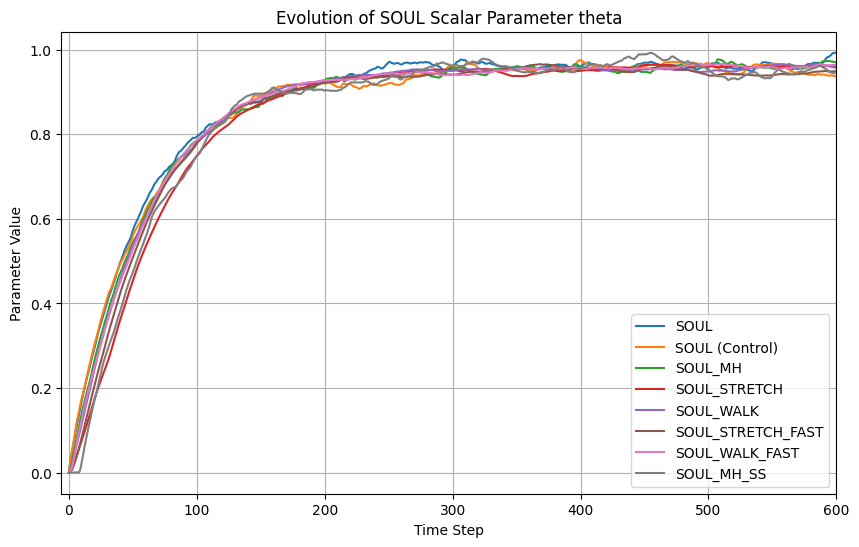

In [38]:
#@title Plot the results
plt.figure(figsize=(10, 6))

plt.plot(th_soul, label='SOUL')
plt.plot(th_ctrl, label='SOUL (Control)')
plt.plot(th_so_mh, label='SOUL_MH')
plt.plot(th_so_stretch, label='SOUL_STRETCH')
plt.plot(th_so_walk, label='SOUL_WALK')
plt.plot(th_so_stretch_fast, label='SOUL_STRETCH_FAST')
plt.plot(th_so_walk_fast, label='SOUL_WALK_FAST')
plt.plot(th_so_mh_ss, label='SOUL_MH_SS')

plt.xlim([-T/100, T])
plt.xlabel('Time Step')
plt.ylabel('Parameter Value')
plt.title('Evolution of SOUL Scalar Parameter theta')
plt.legend()
plt.grid(True)
plt.show()

We obtain the same allure for all our variants.

**SOUL_MH** - proposal_std tuned by hand for a healthy acceptance rate (around 30-40%) proposal_std=0.25 here (0.2 better than 0.3)

**SOUL_MH_SS**
- If theta is oscillating or unstable, decrease delta_step. If theta converges too slowly, you might try increasing it slightly, but be careful not to make it too large, which can lead to divergence.
- Bounds [0.5, 1.5] -> gave negative thetas (why?)
[-5.0, 5.0] works but is a little unstable
[0.0, 5.0] works but is even more unstable (why?)
- tried to decrease theta_step from 1e-2 to 1e-3 for more stability, but slowed convergence way too much.
- adjust proposal_std to have an acceptance rate of 20-50% >> 0.025 gave much better results !!

- Larger T: Allows th_soul_mh_ss more opportunities to converge, potentially leading to a more accurate final estimate if delta_step is well-tuned. It increases computation time.

**SOUL_STRETCH and SOUL_WALK** are very long to run (29min for both with N=10). We would save results on npz files to avoid re-running the code every time we needed to compare to other versions. The more walkers we add, the more precise the result gets, but the longer it is to obtain. Precisely, in this example little imrpovement is seen over 10 walkers, and fewer than that is unsufficient to estimate theta. 
In particular, they would converge lower than soul control on the first tests. This is impossible, so it was probably due to a gradient estimation error. Augmenting N to 10 fixed this.

**SOUL_STRETCH_FAST and SOUL_WALK_FAST** prove to behave correctly, as they display the same results in less time.